# Assignment 1: Loading and Visualizing NYC Harbor Water Quality Data

## tl;dr

This notebook uses 2024 observations from the NYC Department of Environmental Protection's Harbor Water Quality dataset. I focus on **surface dissolved oxygen (DO)** and **surface water temperature** because DO is directly relevant to aquatic life and temperature is one physical factor related to how much oxygen water can hold.

Among the 1,658 records with both measurements, median surface DO was **7.02 mg/L** and median surface temperature was **20.45 degrees C**. About **14.1%** of these measurements were below the general 5 mg/L reference discussed by the EPA. Temperature and DO had a moderately strong negative correlation (**r = -0.61**), but this descriptive relationship does not establish that temperature alone caused the observed DO values.

## Context & Methods

### Question

How did surface dissolved oxygen vary across NYC Harbor sampling stations in 2024, and how was it associated with surface water temperature?

This is a descriptive exploratory analysis. It summarizes where and when NYC DEP collected samples; it is not a compliance determination or a complete assessment of whether any location is safe for swimming, fishing, or drinking.

### Data sources

- Main dataset: [NYC Open Data - Harbor Water Quality](https://data.cityofnewyork.us/Environment/Harbor-Water-Quality/5uug-f49n/about_data), provided by the NYC Department of Environmental Protection (DEP).
- Map context: [NYC Open Data - Borough Boundaries](https://data.cityofnewyork.us/City-Government/Borough-Boundaries/gthc-hcne/about_data), provided by the NYC Department of City Planning.
- Attribute interpretation: [EPA - Indicators: Dissolved Oxygen](https://www.epa.gov/national-aquatic-resource-surveys/indicators-dissolved-oxygen) and [NYC DEP - New York Harbor Survey Program](https://www.nyc.gov/assets/dep/downloads/pdf/water/nyc-waterways/harbor-water-quality-report/new-york-harbor-survey-program.pdf).

The analysis year is fixed at 2024 so the notebook is reproducible and represents a complete recent calendar year. The 2024 rows do not include usable latitude/longitude values, so station locations are matched by `sampling_location` to median coordinates from 2019 records in the same dataset. One station with 2024 DO data (`NC0B`) has no valid 2019 coordinate and is omitted from the map, but remains in the non-map analysis.

### Key assumptions

- A sampling station code refers to the same general location in 2019 and 2024.
- Taking the median of repeated samples gives a useful description of a station's typical 2024 condition, although it hides short-term extremes.
- The EPA's 5 mg/L value is included only as a general ecological reference. Species, season, salinity, depth, time of day, and local water-quality standards can change how a DO value should be interpreted.

## Setup

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import requests
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "font.size": 10,
    "axes.edgecolor": "#5f6b73",
    "axes.labelcolor": "#263238",
    "xtick.color": "#4f5b62",
    "ytick.color": "#4f5b62",
})

ANALYSIS_YEAR = 2024
COORDINATE_YEAR = 2019
DATASET_ID = "5uug-f49n"
DATA_API_URL = f"https://data.cityofnewyork.us/resource/{DATASET_ID}.json"
METADATA_URL = f"https://data.cityofnewyork.us/api/views/{DATASET_ID}"
BOROUGH_GEOJSON_URL = "https://data.cityofnewyork.us/resource/gthc-hcne.geojson?$limit=10"

BLUE = "#1f6f8b"
DARK_BLUE = "#174a5b"
ORANGE = "#d9822b"
GRID = "#dfe5e8"

## Data

### 1. Inspect the dataset metadata

The NYC Open Data metadata describes the source, update schedule, and available fields. I also ask the API for the dataset's row count and date coverage rather than assuming the current size from the website.

In [10]:
metadata_response = requests.get(METADATA_URL, timeout=60)
metadata_response.raise_for_status()
metadata = metadata_response.json()

overview_params = {
    "$select": "count(*) as rows, min(sample_date) as first_date, max(sample_date) as last_date"
}
overview_response = requests.get(DATA_API_URL, params=overview_params, timeout=60)
overview_response.raise_for_status()
overview = overview_response.json()[0]

custom_fields = metadata.get("metadata", {}).get("custom_fields", {})
metadata_summary = pd.DataFrame({
    "Item": [
        "Dataset title",
        "Provider",
        "Description",
        "Update frequency",
        "Rows currently available",
        "First sample date",
        "Last sample date",
        "Number of columns",
    ],
    "Value": [
        metadata.get("name"),
        metadata.get("attribution"),
        metadata.get("description"),
        custom_fields.get("Update", {}).get("Update Frequency"),
        f"{int(overview['rows']):,}",
        overview.get("first_date", "")[:10],
        overview.get("last_date", "")[:10],
        len(metadata.get("columns", [])),
    ],
})
metadata_summary

,Item,Value
0,Dataset title,Harbor Water Quality
1,Provider,Department of Environmental Protection (DEP)
2,Description,Harbor water sampling information
3,Update frequency,Weekly
4,Rows currently available,"98,288"
5,First sample date,1909-03-23
6,Last sample date,2025-12-16
7,Number of columns,100


### 2. Choose two attributes

The dataset contains many water-quality fields. I narrowed the analysis to these two because together they support a clear spatial question and a clear relationship question.

| API field | Meaning | Why I selected it |
|---|---|---|
| `ctd_conductivity_temperature_depth_profiler_top_dissolved_oxygen_mg_l` | Dissolved oxygen measured near the surface, in milligrams per liter | DO indicates how much oxygen is available in the water for aquatic organisms. |
| `top_sample_temperature_c` | Near-surface water temperature, in degrees Celsius | Temperature affects oxygen solubility and provides a plausible physical context for DO variation. |

**What they can tell us:** the measured condition at a particular station and sampling time, the distribution of observed values, spatial differences in station medians, and whether temperature and DO move together in this sample.

**What they cannot tell us alone:** whether the water is safe for people, whether pollutants or bacteria are present, conditions between sampling events, bottom-water conditions, or the cause of a low DO measurement.

### 3. Load a bounded subset from the API

The API request selects only the fields and year needed for this assignment. A second small request obtains 2019 station coordinates, and a five-feature borough dataset provides geographic context.

In [11]:
analysis_fields = [
    "sampling_location",
    "sample_date",
    "top_sample_temperature_c",
    "ctd_conductivity_temperature_depth_profiler_top_dissolved_oxygen_mg_l",
]
analysis_params = {
    "$select": ",".join(analysis_fields),
    "$where": (
        f"sample_date between '{ANALYSIS_YEAR}-01-01T00:00:00.000' "
        f"and '{ANALYSIS_YEAR}-12-31T23:59:59.999'"
    ),
    "$limit": 50000,
}
analysis_response = requests.get(DATA_API_URL, params=analysis_params, timeout=60)
analysis_response.raise_for_status()
water_raw = pd.DataFrame(analysis_response.json())

coordinate_params = {
    "$select": "sampling_location,long,lat",
    "$where": (
        f"sample_date between '{COORDINATE_YEAR}-01-01T00:00:00.000' "
        f"and '{COORDINATE_YEAR}-12-31T23:59:59.999'"
    ),
    "$limit": 50000,
}
coordinate_response = requests.get(DATA_API_URL, params=coordinate_params, timeout=60)
coordinate_response.raise_for_status()
coordinates_raw = pd.DataFrame(coordinate_response.json())

borough_response = requests.get(BOROUGH_GEOJSON_URL, timeout=60)
borough_response.raise_for_status()
boroughs = gpd.GeoDataFrame.from_features(
    borough_response.json()["features"], crs="EPSG:4326"
)

print(f"2024 water-quality rows loaded: {len(water_raw):,}")
print(f"2019 coordinate rows loaded: {len(coordinates_raw):,}")
print(f"Borough polygons loaded: {len(boroughs):,}")
display(water_raw.head())

2024 water-quality rows loaded: 2,116
2019 coordinate rows loaded: 2,130
Borough polygons loaded: 5


,sampling_location,sample_date,top_sample_temperature_c,ctd_conductivity_temperature_depth_profiler_top_dissolved_oxygen_mg_l
0,G2,2024-01-08T00:00:00.000,5.86915,9.4
1,N7,2024-01-08T00:00:00.000,5.94705,9.3519
2,NC0,2024-01-08T00:00:00.000,5.2563,4.5541
3,NC0B,2024-01-08T00:00:00.000,6.16295,5.569
4,NC1,2024-01-08T00:00:00.000,5.88985,6.9224


### 4. Clean numeric fields and check missing values

NYC Open Data stores the selected measurements and coordinates as text. I convert them to numbers with invalid text becoming `NaN`. I also keep only coordinates inside a broad NYC Harbor bounding box; this removes 16 coordinate records with implausible latitude values instead of silently plotting them far from New York.

In [12]:
water = water_raw.rename(columns={
    "top_sample_temperature_c": "temperature_c",
    "ctd_conductivity_temperature_depth_profiler_top_dissolved_oxygen_mg_l": "dissolved_oxygen_mg_l",
}).copy()
water["sample_date"] = pd.to_datetime(water["sample_date"], errors="coerce")
water["temperature_c"] = pd.to_numeric(water["temperature_c"], errors="coerce")
water["dissolved_oxygen_mg_l"] = pd.to_numeric(
    water["dissolved_oxygen_mg_l"], errors="coerce"
)

coordinates = coordinates_raw.copy()
coordinates["longitude"] = pd.to_numeric(
    coordinates["long"].astype(str).str.replace(" ", "", regex=False).str.strip(),
    errors="coerce",
)
coordinates["latitude"] = pd.to_numeric(
    coordinates["lat"].astype(str).str.replace(" ", "", regex=False).str.strip(),
    errors="coerce",
)

valid_coordinate_mask = (
    coordinates["longitude"].between(-74.30, -73.65)
    & coordinates["latitude"].between(40.45, 40.95)
)
valid_coordinates = coordinates.loc[valid_coordinate_mask].copy()
station_coordinates = (
    valid_coordinates.groupby("sampling_location", as_index=False)
    .agg(longitude=("longitude", "median"), latitude=("latitude", "median"))
)

data_quality = pd.DataFrame({
    "Check": [
        "Raw 2024 rows",
        "Rows with surface temperature",
        "Rows with surface DO",
        "Rows with both selected attributes",
        "2019 coordinate rows outside NYC bounds",
    ],
    "Count": [
        len(water),
        water["temperature_c"].notna().sum(),
        water["dissolved_oxygen_mg_l"].notna().sum(),
        water[["temperature_c", "dissolved_oxygen_mg_l"]].notna().all(axis=1).sum(),
        (~valid_coordinate_mask).sum(),
    ],
})
data_quality

,Check,Count
0,Raw 2024 rows,2116
1,Rows with surface temperature,1669
2,Rows with surface DO,1658
3,Rows with both selected attributes,1658
4,2019 coordinate rows outside NYC bounds,16


### 5. Build sample-level and station-level analysis tables

The scatter plot uses only records that contain both selected attributes. The map uses the median DO at each station so stations sampled more often do not receive more visual weight simply because they have more rows.

In [13]:
paired_samples = water.dropna(
    subset=["temperature_c", "dissolved_oxygen_mg_l"]
).copy()

station_summary = (
    water.dropna(subset=["dissolved_oxygen_mg_l"])
    .groupby("sampling_location", as_index=False)
    .agg(
        sample_count=("dissolved_oxygen_mg_l", "size"),
        median_do_mg_l=("dissolved_oxygen_mg_l", "median"),
        median_temperature_c=("temperature_c", "median"),
    )
    .merge(station_coordinates, on="sampling_location", how="left")
)

mapped_stations = station_summary.dropna(subset=["longitude", "latitude"]).copy()
station_gdf = gpd.GeoDataFrame(
    mapped_stations,
    geometry=gpd.points_from_xy(mapped_stations["longitude"], mapped_stations["latitude"]),
    crs="EPSG:4326",
)

summary_statistics = paired_samples[["temperature_c", "dissolved_oxygen_mg_l"]].describe().T
summary_statistics.index = ["Surface temperature (degrees C)", "Surface dissolved oxygen (mg/L)"]

correlation = paired_samples["temperature_c"].corr(
    paired_samples["dissolved_oxygen_mg_l"]
)
below_five_share = (paired_samples["dissolved_oxygen_mg_l"] < 5).mean()

display(summary_statistics.round(2))
print(f"Mapped stations: {len(station_gdf)} of {len(station_summary)} stations with DO data")
print(f"Temperature-DO Pearson correlation: {correlation:.2f}")
print(f"Share of complete-pair measurements below 5 mg/L: {below_five_share:.1%}")

,count,mean,std,min,25%,50%,75%,max
Surface temperature (degrees C),1658.0,18.81,5.89,2.37,15.99,20.45,23.13,28.49
Surface dissolved oxygen (mg/L),1658.0,7.63,2.95,0.45,5.66,7.02,8.99,19.64


Mapped stations: 57 of 58 stations with DO data
Temperature-DO Pearson correlation: -0.61
Share of complete-pair measurements below 5 mg/L: 14.1%


## Results

### 1. Map: station-level dissolved oxygen

This map answers the spatial question: **where were typical surface DO measurements lower or higher among the sampled stations?** Color represents each station's median, not a continuous estimate for all water between stations.

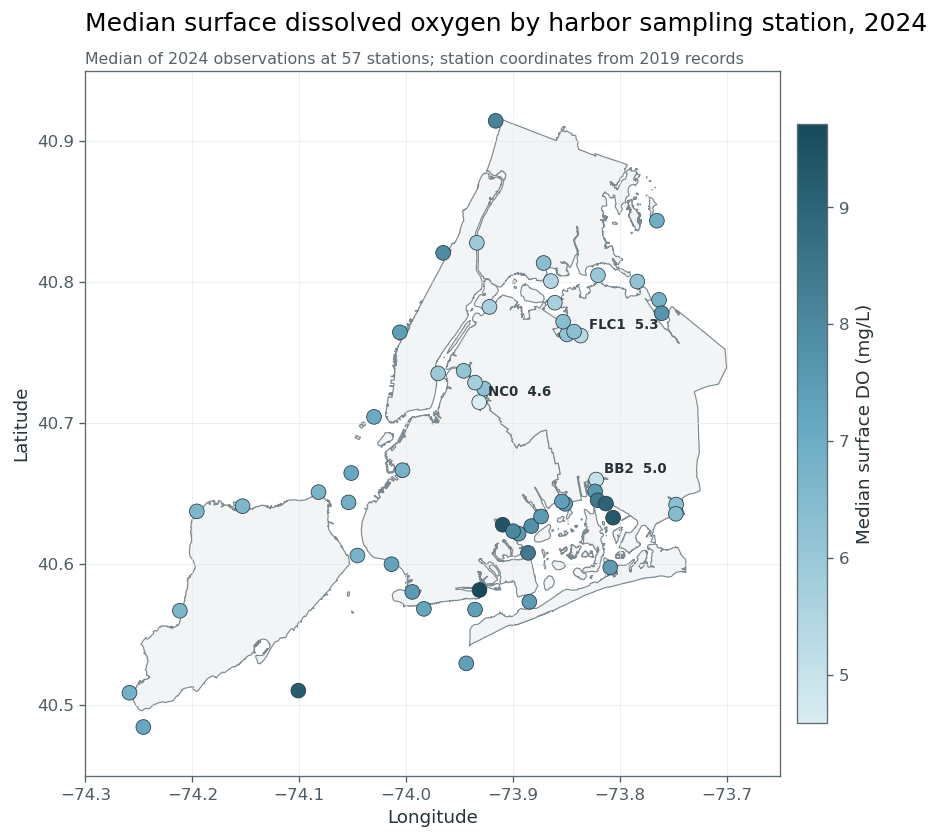

In [14]:
do_cmap = LinearSegmentedColormap.from_list(
    "dissolved_oxygen", ["#d9edf2", "#66a9c2", "#174a5b"]
)

fig, ax = plt.subplots(figsize=(9, 9))
boroughs.plot(ax=ax, color="#f2f4f5", edgecolor="#7d8990", linewidth=0.7, zorder=1)
station_gdf.plot(
    ax=ax,
    column="median_do_mg_l",
    cmap=do_cmap,
    markersize=78,
    edgecolor="#24353d",
    linewidth=0.45,
    legend=True,
    legend_kwds={"label": "Median surface DO (mg/L)", "shrink": 0.72, "pad": 0.02},
    zorder=3,
)

for _, row in station_gdf.nsmallest(3, "median_do_mg_l").iterrows():
    ax.annotate(
        f"{row['sampling_location']}  {row['median_do_mg_l']:.1f}",
        xy=(row.geometry.x, row.geometry.y),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
        weight="bold",
        color="#263238",
        zorder=4,
    )

ax.set_xlim(-74.30, -73.65)
ax.set_ylim(40.45, 40.95)
ax.set_title("Median surface dissolved oxygen by harbor sampling station, 2024", loc="left", pad=24)
ax.text(
    0,
    1.01,
    f"Median of 2024 observations at {len(station_gdf)} stations; station coordinates from 2019 records",
    transform=ax.transAxes,
    fontsize=9.5,
    color="#56636a",
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(color=GRID, linewidth=0.5, alpha=0.7, zorder=0)
plt.show()

The mapped station medians range from **4.59 mg/L at NC0** to **9.71 mg/L at J11**. The map reveals differences among sampled locations, including several lower medians in tributary or enclosed-water stations. It does **not** show conditions everywhere in the harbor: unsampled areas are blank, point colors should not be read as continuous surfaces, and each median compresses multiple dates into one value.

### 2. Non-map visualization: distribution of dissolved oxygen

The histogram shows the full sample-level distribution that the station medians hide. The 5 mg/L line is a general EPA ecological reference, not a NYC Harbor compliance test.

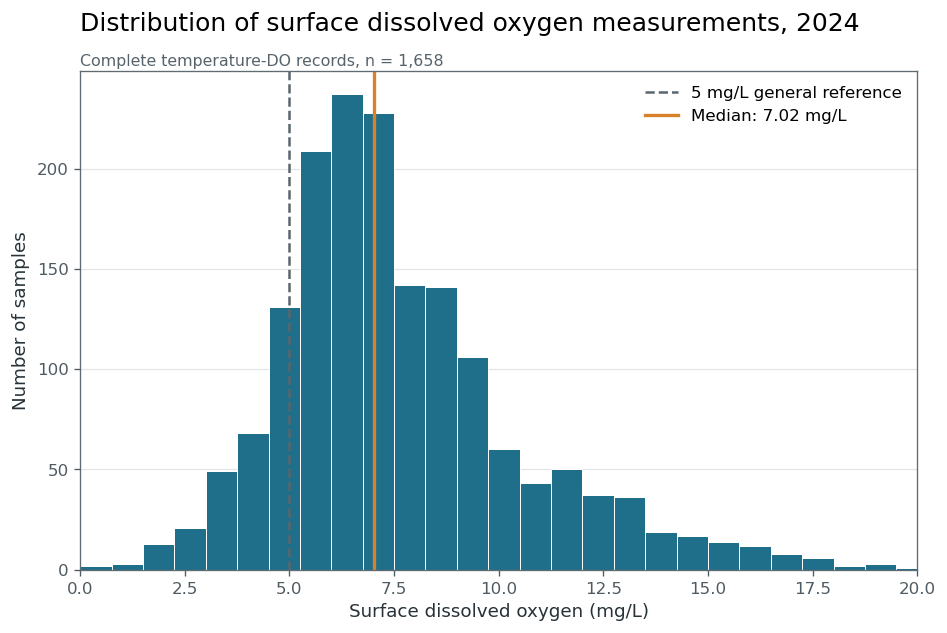

In [15]:
median_do = paired_samples["dissolved_oxygen_mg_l"].median()

fig, ax = plt.subplots(figsize=(9, 5.4))
ax.hist(
    paired_samples["dissolved_oxygen_mg_l"],
    bins=np.arange(0, 20.5, 0.75),
    color=BLUE,
    edgecolor="white",
    linewidth=0.6,
)
ax.axvline(5, color="#59666d", linestyle="--", linewidth=1.5, label="5 mg/L general reference")
ax.axvline(median_do, color=ORANGE, linewidth=2, label=f"Median: {median_do:.2f} mg/L")
ax.set_title("Distribution of surface dissolved oxygen measurements, 2024", loc="left", pad=24)
ax.text(
    0,
    1.01,
    f"Complete temperature-DO records, n = {len(paired_samples):,}",
    transform=ax.transAxes,
    fontsize=9.5,
    color="#56636a",
)
ax.set_xlabel("Surface dissolved oxygen (mg/L)")
ax.set_ylabel("Number of samples")
ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
ax.grid(axis="y", color=GRID, linewidth=0.7)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper right")
plt.show()

The distribution is broad: complete-pair observations range from **0.45 to 19.64 mg/L**, and **14.1%** fall below 5 mg/L. This numeric summary identifies low observations, but it cannot tell whether each low value persisted, whether it occurred at a biologically sensitive depth or time, or whether it violated the standard applicable to that specific water body.

### 3. Non-map visualization: temperature and dissolved oxygen

The scatter plot uses one point per complete sample. A fitted line summarizes the direction of association; it is not a causal model.

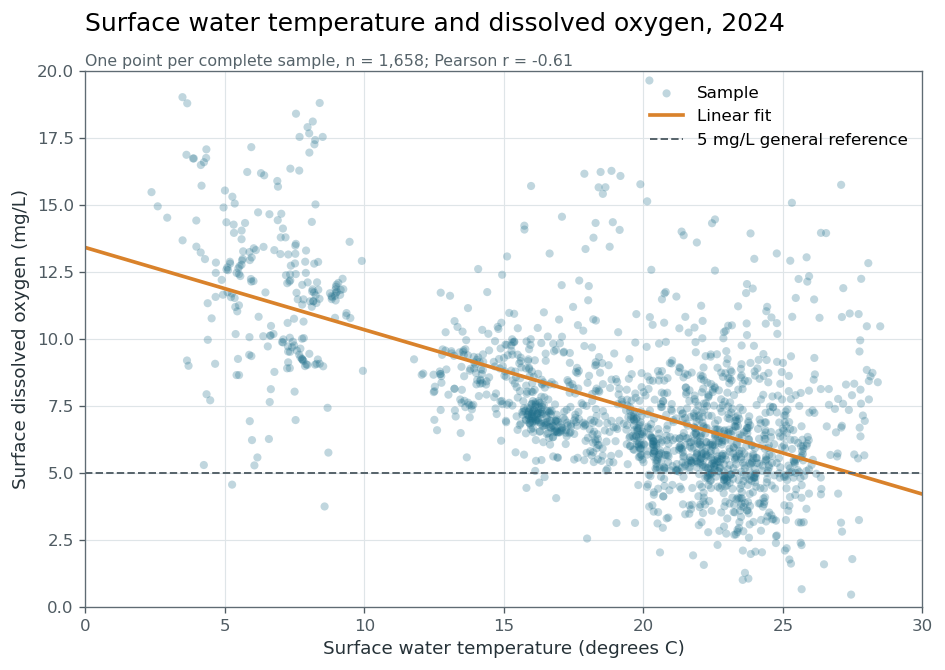

In [16]:
x = paired_samples["temperature_c"].to_numpy()
y = paired_samples["dissolved_oxygen_mg_l"].to_numpy()
slope, intercept = np.polyfit(x, y, 1)
x_line = np.linspace(0, 30, 200)

fig, ax = plt.subplots(figsize=(9, 5.8))
ax.scatter(x, y, s=24, color=BLUE, alpha=0.28, edgecolors="none", label="Sample")
ax.plot(x_line, slope * x_line + intercept, color=ORANGE, linewidth=2.2, label="Linear fit")
ax.axhline(5, color="#59666d", linestyle="--", linewidth=1.2, label="5 mg/L general reference")
ax.set_title("Surface water temperature and dissolved oxygen, 2024", loc="left", pad=24)
ax.text(
    0,
    1.01,
    f"One point per complete sample, n = {len(paired_samples):,}; Pearson r = {correlation:.2f}",
    transform=ax.transAxes,
    fontsize=9.5,
    color="#56636a",
)
ax.set_xlabel("Surface water temperature (degrees C)")
ax.set_ylabel("Surface dissolved oxygen (mg/L)")
ax.set_xlim(0, 30)
ax.set_ylim(0, 20)
ax.grid(color=GRID, linewidth=0.7)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="upper right")
plt.show()

The scatter plot shows a negative association (**r = -0.61**): warmer samples generally had lower dissolved oxygen. That pattern is physically plausible because warmer water can hold less oxygen. However, this plot cannot isolate temperature's effect from season, location, salinity, weather, biological activity, wastewater inputs, or sampling time. Repeated observations from the same stations also are not statistically independent.

## Takeaways

1. Surface DO varied substantially across both samples and stations in 2024. The sample median was **7.02 mg/L**, while mapped station medians ranged from **4.59 to 9.71 mg/L**.
2. **14.1%** of complete temperature-DO records were below the general 5 mg/L reference, showing that a median alone would hide a meaningful lower tail.
3. Water temperature and DO were negatively correlated (**r = -0.61**), but this notebook supports a descriptive association, not a causal conclusion.
4. The attributes are useful for describing sampled surface-water conditions and identifying places or times for closer study. They cannot by themselves establish overall water quality, human-health safety, legal compliance, or conditions in unsampled locations and times.

### Next analytical step

A follow-up could compare seasons or wet-versus-dry weather within the same stations, or map multiple years to test whether the spatial pattern is persistent. That would require careful treatment of repeated measurements and changing station coverage.